<a href="https://colab.research.google.com/github/aarav06-bit/CS131_release/blob/master/spring_2026/crystal_density_classification/crystal_density_calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ase

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ase.build import bulk

from scipy.ndimage import gaussian_filter
from scipy.ndimage import rotate
import os
import pandas as pd
from skimage.feature import peak_local_max

In [3]:
MATERIALS = [

    # FCC
    {'element': 'Au', 'structure': 'fcc', 'a': 4.08},
    {'element': 'Al', 'structure': 'fcc', 'a': 4.05},
    {'element': 'Cu', 'structure': 'fcc', 'a': 3.61},
    {'element': 'Ni', 'structure': 'fcc', 'a': 3.52},
    {'element': 'Ag', 'structure': 'fcc', 'a': 4.09},
    {'element': 'Pt', 'structure': 'fcc', 'a': 3.92},

    # BCC
    {'element': 'Fe', 'structure': 'bcc', 'a': 2.87},
    {'element': 'Cr', 'structure': 'bcc', 'a': 2.91},
    {'element': 'W',  'structure': 'bcc', 'a': 3.16},
    {'element': 'Mo', 'structure': 'bcc', 'a': 3.15},
    {'element': 'Nb', 'structure': 'bcc', 'a': 3.30},
    {'element': 'V',  'structure': 'bcc', 'a': 3.03},

    # HCP
    {'element': 'Ti', 'structure': 'hcp', 'a': 2.95, 'c': 4.68},
    {'element': 'Mg', 'structure': 'hcp', 'a': 3.21, 'c': 5.21},
    {'element': 'Zn', 'structure': 'hcp', 'a': 2.66, 'c': 4.95},
    {'element': 'Co', 'structure': 'hcp', 'a': 2.51, 'c': 4.07},
    {'element': 'Zr', 'structure': 'hcp', 'a': 3.23, 'c': 5.15},
    {'element': 'Be', 'structure': 'hcp', 'a': 2.29, 'c': 3.58},
]

In [4]:
AVOGADRO = 6.022e23

ATOMS_PER_CELL = {
    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

def compute_density(structure, mass, lattice_constant):

    n = ATOMS_PER_CELL[structure]

    # convert angstroms to cm
    a_cm = lattice_constant * 1e-8

    volume = a_cm**3

    density = (n * mass) / (AVOGADRO * volume)

    return density

In [5]:
def generate_crystal_image(
    material,
    repetitions=(8,8,4),
    grid_size=128,
    sigma=2,
    noise_level=0.01,
    rotation_angle=0
):

    structure = material['structure']

    # Create crystal
    if structure == 'hcp':

        atoms = bulk(
            material['element'],
            structure,
            a=material['a'],
            c=material['c']
        )

    else:

        atoms = bulk(
            material['element'],
            structure,
            a=material['a']
        )

    atoms = atoms.repeat(repetitions)

    # Atomic positions
    positions = atoms.get_positions()

    x = positions[:,0]
    y = positions[:,1]

    # Normalize coordinates
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # Create image
    image = np.zeros((grid_size, grid_size))

    x_pix = (x_norm * (grid_size - 1)).astype(int)
    y_pix = (y_norm * (grid_size - 1)).astype(int)

    # Place atoms
    for xp, yp in zip(x_pix, y_pix):
        image[yp, xp] += 1

    # Blur
    image = gaussian_filter(image, sigma=sigma)

    # Rotate
    image = rotate(
        image,
        angle=rotation_angle,
        reshape=False
    )

    # Add noise
    noise = np.random.normal(
        0,
        noise_level,
        image.shape
    )

    image += noise

    # Normalize
    image -= image.min()
    image /= image.max()

    return image

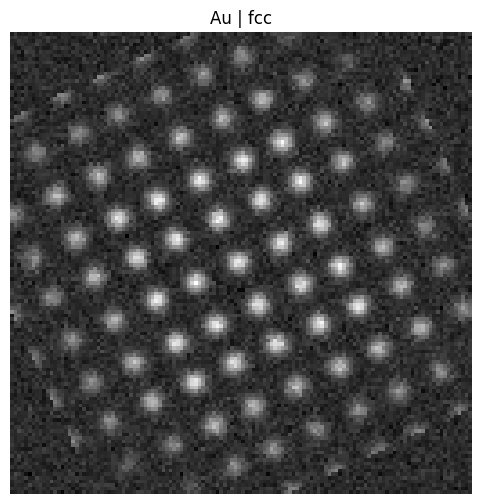

In [6]:

material = MATERIALS[0]
image = generate_crystal_image(
    material,
    rotation_angle=25
)
plt.figure(figsize=(6,6))

plt.imshow(image, cmap='gray')

plt.title(
    f"{material['element']} | "
    f"{material['structure']}"
)

plt.axis('off')

plt.show()

In [7]:

os.makedirs("dataset/images", exist_ok=True)
metadata_list = []
sample_id = 0
for material in MATERIALS:
    for rotation in range(0, 180, 15):
        for noise_level in [0.005, 0.01, 0.02]:
            image = generate_crystal_image(
                material,
                rotation_angle=rotation,
                noise_level=noise_level
            )
            filename = f"sample_{sample_id:04d}.npy"
            np.save(
                f"dataset/images/{filename}",
                image
            )
            metadata_list.append({
                'filename': filename,
                'element': material['element'],
                'structure': material['structure'],
                'rotation': rotation,
                'noise_level': noise_level
            })
            sample_id += 1
metadata_df = pd.DataFrame(metadata_list)
metadata_df.to_csv("dataset/metadata.csv",index=False)
print("Dataset generation complete.")
print(f"Total samples: {sample_id}")

Dataset generation complete.
Total samples: 648


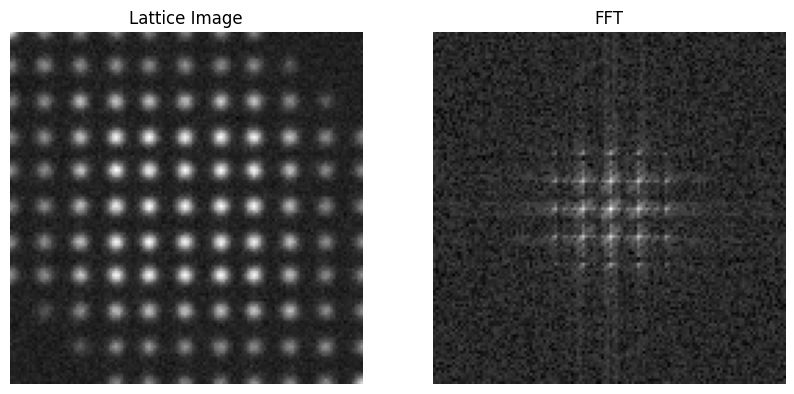

In [22]:
sample = np.load("dataset/images/sample_0000.npy")

fft = np.fft.fftshift(
    np.fft.fft2(sample)
)

magnitude = np.log(np.abs(fft) + 1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(sample, cmap='gray')

plt.title("Lattice Image")

plt.axis('off')

plt.subplot(1,2,2)

plt.imshow(magnitude, cmap='gray')

plt.title("FFT")

plt.axis('off')

plt.show()

In [21]:
from skimage import filters
from scipy.ndimage import convolve
from skimage.feature import corner_peaks


def harris_corners(img, window_size=3, k=0.04):
    """
    Compute Harris corner response map. R = Det(M) - k*Trace(M)^2.
    From CS 131 Project 1.
    """
    H, W = img.shape
    window = np.ones((window_size, window_size))

    # Compute x and y derivatives
    dx = filters.sobel_v(img)
    dy = filters.sobel_h(img)

    Ixx = dx * dx
    Iyy = dy * dy
    Ixy = dx * dy

    # Sum over window
    Sxx = convolve(Ixx, window, mode='constant', cval=0)
    Syy = convolve(Iyy, window, mode='constant', cval=0)
    Sxy = convolve(Ixy, window, mode='constant', cval=0)

    # Harris response
    det_M = Sxx * Syy - Sxy * Sxy
    trace_M = Sxx + Syy

    response = det_M - k * (trace_M ** 2)

    return response

Detected coordinates:
[[64 64]
 [54 74]
 [74 54]
 [54 54]
 [74 74]
 [64 54]
 [64 74]
 [74 64]
 [54 64]
 [64 44]
 [64 84]
 [84 74]
 [44 54]
 [84 64]
 [44 64]
 [74 84]
 [54 44]
 [84 54]
 [44 74]
 [54 84]]

Peak distances:
[14.14213562 14.14213562 14.14213562 14.14213562 10.         10.
 10.         10.         20.         20.         22.36067977 22.36067977
 20.         20.         22.36067977 22.36067977 22.36067977 22.36067977
 22.36067977]


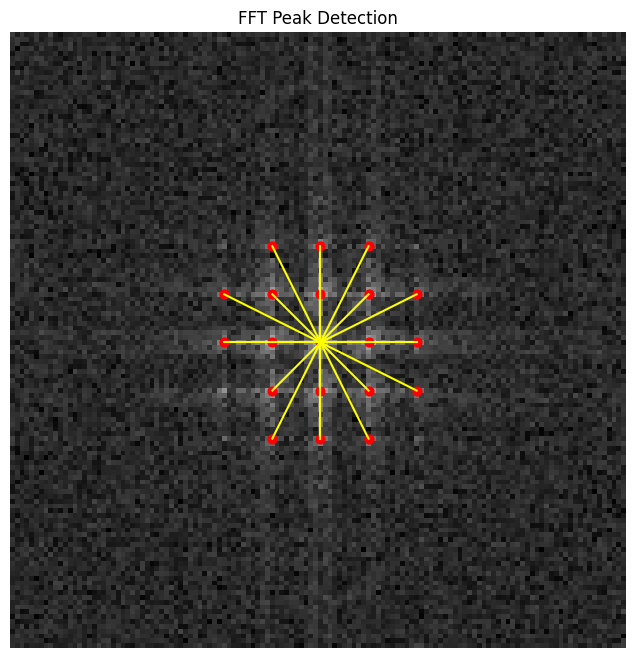

In [23]:

sample = np.load("dataset/images/sample_0000.npy")
fft = np.fft.fftshift(np.fft.fft2(sample))
magnitude = np.log(np.abs(fft) + 1)
response = harris_corners(magnitude, window_size=3, k=0.04)

coordinates = corner_peaks(
    response,
    threshold_rel=0.05,
    exclude_border=8,
    num_peaks=20
)

print("Detected coordinates:")
print(coordinates)

# FFT center
center_y = magnitude.shape[0] // 2
center_x = magnitude.shape[1] // 2

# Compute distances from center
distances = []

for coord in coordinates:

    y, x = coord

    # Skip center peak
    if abs(x - center_x) < 5 and abs(y - center_y) < 5:
        continue

    distance = np.sqrt(
        (x - center_x)**2 +
        (y - center_y)**2
    )

    distances.append(distance)

distances = np.array(distances)

print("\nPeak distances:")
print(distances)

# Visualize FFT peaks
plt.figure(figsize=(8,8))

plt.imshow(magnitude, cmap='gray')

plt.scatter(
    coordinates[:,1],
    coordinates[:,0],
    c='red',
    s=40
)

for coord in coordinates:
    y, x = coord
    plt.plot(
        [center_x, x],
        [center_y, y],
        'yellow'
    )

plt.title("FFT Peak Detection")
plt.axis('off')
plt.show()

In [10]:

mean_distance = np.mean(distances)

std_distance = np.std(distances)

min_distance = np.min(distances)

max_distance = np.max(distances)

num_peaks = len(distances)

print("Mean distance:", mean_distance)

print("Std distance:", std_distance)

print("Min distance:", min_distance)

print("Max distance:", max_distance)

print("Number of peaks:", num_peaks)

Mean distance: 17.53122636420574
Std distance: 4.922910677170428
Min distance: 10.0
Max distance: 22.360679774997898
Number of peaks: 19


In [29]:
distance_feature_data = []

for idx in range(len(metadata_df)):

    filename = metadata_df.iloc[idx]['filename']
    structure = metadata_df.iloc[idx]['structure']
    image = np.load(f"dataset/images/{filename}")

    # Compute FFT
    fft = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log(np.abs(fft) + 1)

    # Harris corner detection on FFT
    response = harris_corners(magnitude,window_size=3,k=0.04)

    coordinates = corner_peaks(
      response,
      threshold_rel=0.05,
      exclude_border=8,
      num_peaks=20
    )

    center_y = magnitude.shape[0] // 2
    center_x = magnitude.shape[1] // 2

    distances = []
    for coord in coordinates:
        y, x = coord
        if abs(x - center_x) < 5 and abs(y - center_y) < 5:
            continue
        distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        distances.append(distance)

    distances = np.array(distances)

    if len(distances) == 0:
        continue

    distance_feature_data.append({
        'filename': filename,
        'mean_distance': np.mean(distances),
        'std_distance': np.std(distances),
        'min_distance': np.min(distances),
        'max_distance': np.max(distances),
        'num_peaks': len(distances),
        'structure': structure
    })

distance_features_df = pd.DataFrame(distance_feature_data)
print(distance_features_df.head())

          filename  mean_distance  std_distance  min_distance  max_distance  \
0  sample_0000.npy      17.531226      4.922911     10.000000     22.360680   
1  sample_0001.npy      17.533856      4.924235     10.000000     22.360680   
2  sample_0002.npy      14.128990      4.513495     10.000000     22.360680   
3  sample_0003.npy      17.319567      4.971600      9.486833     22.671568   
4  sample_0004.npy      17.512970      4.917800     10.198039     22.671568   

   num_peaks structure  
0         19       fcc  
1         19       fcc  
2         10       fcc  
3         19       fcc  
4         18       fcc  


In [28]:
angular_feature_data = []

for idx in range(len(metadata_df)):

    filename = metadata_df.iloc[idx]['filename']
    image = np.load(f"dataset/images/{filename}")

    # Compute FFT
    fft = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log(np.abs(fft) + 1)

    # Harris corner detection on FFT
    response = harris_corners(magnitude,window_size=3,k=0.04)

    coordinates = corner_peaks(
      response,
      threshold_rel=0.05,
      exclude_border=8,
      num_peaks=20
    )

    center_y = magnitude.shape[0] // 2
    center_x = magnitude.shape[1] // 2

    angles = []
    for coord in coordinates:
        y, x = coord
        if abs(x - center_x) < 5 and abs(y - center_y) < 5:
            continue
        angle = np.degrees(np.arctan2(y - center_y, x - center_x)) % 360
        angles.append(angle)

    angles = np.array(angles)

    if len(angles) < 2:
        continue

    angles_sorted = np.sort(angles)
    angular_diffs = np.diff(angles_sorted)

    angular_feature_data.append({
        'filename': filename,
        'mean_angular_diff': np.mean(angular_diffs),
        'std_angular_diff': np.std(angular_diffs),
    })

angular_features_df = pd.DataFrame(angular_feature_data)
print(angular_features_df.head())

          filename  mean_angular_diff  std_angular_diff
0  sample_0000.npy          18.524164         11.694109
1  sample_0001.npy          18.524164         11.030647
2  sample_0002.npy          35.000000         11.504099
3  sample_0003.npy          17.690757         10.406986
4  sample_0004.npy          19.757988         12.275853


In [30]:
features_df = distance_features_df.merge(angular_features_df, on='filename')
print(features_df.head())

          filename  mean_distance  std_distance  min_distance  max_distance  \
0  sample_0000.npy      17.531226      4.922911     10.000000     22.360680   
1  sample_0001.npy      17.533856      4.924235     10.000000     22.360680   
2  sample_0002.npy      14.128990      4.513495     10.000000     22.360680   
3  sample_0003.npy      17.319567      4.971600      9.486833     22.671568   
4  sample_0004.npy      17.512970      4.917800     10.198039     22.671568   

   num_peaks structure  mean_angular_diff  std_angular_diff  
0         19       fcc          18.524164         11.694109  
1         19       fcc          18.524164         11.030647  
2         10       fcc          35.000000         11.504099  
3         19       fcc          17.690757         10.406986  
4         18       fcc          19.757988         12.275853  


In [31]:
features_df['structure'].value_counts()

,count
structure,
fcc,216
bcc,216
hcp,216


In [32]:
from sklearn.model_selection import train_test_split

X = features_df[[
    'mean_distance',
    'std_distance',
    'min_distance',
    'max_distance',
    'num_peaks',
    'mean_angular_diff',
    'std_angular_diff',
]]

y = features_df['structure']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

Training samples: 518
Testing samples: 130


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create classifier
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train classifier
classifier.fit(X_train, y_train)

# Predict structures
predictions = classifier.predict(X_test)

# Display results
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

         bcc       1.00      1.00      1.00        39
         fcc       1.00      1.00      1.00        50
         hcp       1.00      1.00      1.00        41

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



In [34]:
STRUCTURE_INFO = {

    'fcc': 4,
    'bcc': 2,
    'hcp': 6
}

In [35]:
MATERIAL_PROPERTIES = {

    # FCC
    'Au': {'structure': 'fcc', 'a': 4.08, 'atomic_mass': 196.97},
    'Al': {'structure': 'fcc', 'a': 4.05, 'atomic_mass': 26.98},
    'Cu': {'structure': 'fcc', 'a': 3.61, 'atomic_mass': 63.55},
    'Ni': {'structure': 'fcc', 'a': 3.52, 'atomic_mass': 58.69},
    'Ag': {'structure': 'fcc', 'a': 4.09, 'atomic_mass': 107.87},
    'Pt': {'structure': 'fcc', 'a': 3.92, 'atomic_mass': 195.08},

    # BCC
    'Fe': {'structure': 'bcc', 'a': 2.87, 'atomic_mass': 55.85},
    'Cr': {'structure': 'bcc', 'a': 2.91, 'atomic_mass': 52.00},
    'W':  {'structure': 'bcc', 'a': 3.16, 'atomic_mass': 183.84},
    'Mo': {'structure': 'bcc', 'a': 3.15, 'atomic_mass': 95.95},
    'Nb': {'structure': 'bcc', 'a': 3.30, 'atomic_mass': 92.91},
    'V':  {'structure': 'bcc', 'a': 3.03, 'atomic_mass': 50.94},

    # HCP
    'Ti': {'structure': 'hcp', 'a': 2.95, 'c': 4.68, 'atomic_mass': 47.87},
    'Mg': {'structure': 'hcp', 'a': 3.21, 'c': 5.21, 'atomic_mass': 24.31},
    'Zn': {'structure': 'hcp', 'a': 2.66, 'c': 4.95, 'atomic_mass': 65.38},
    'Co': {'structure': 'hcp', 'a': 2.51, 'c': 4.07, 'atomic_mass': 58.93},
    'Zr': {'structure': 'hcp', 'a': 3.23, 'c': 5.15, 'atomic_mass': 91.22},
    'Be': {'structure': 'hcp', 'a': 2.29, 'c': 3.58, 'atomic_mass': 9.01},
}

In [36]:
NA = 6.022e23

def calculate_density(material_name, predicted_structure):

    material = MATERIAL_PROPERTIES[material_name]

    atomic_mass = material['atomic_mass']

    n = STRUCTURE_INFO[predicted_structure]

    # FCC and BCC
    if predicted_structure in ['fcc', 'bcc']:

        a = material['a'] * 1e-8

        volume = a**3

    # HCP
    elif predicted_structure == 'hcp':

        a = material['a'] * 1e-8

        c = material['c'] * 1e-8

        volume = (3 * np.sqrt(3) / 2) * (a**2) * c

    density = (n * atomic_mass) / (volume * NA)

    return density

In [37]:
# Example image index
sample_idx = 0

# True material from metadata
material_name = metadata_df.iloc[sample_idx]['element']

# Fourier features for this sample
sample_features = X.iloc[[sample_idx]]

# Predict structure using ML model
predicted_structure = classifier.predict(sample_features)[0]

# Compute density using predicted structure
predicted_density = calculate_density(
    material_name,
    predicted_structure
)

print("Material:", material_name)

print("Predicted structure:", predicted_structure)

print("Predicted density:", predicted_density)

Material: Au
Predicted structure: fcc
Predicted density: 19.263661391121232
